In [2]:
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import grangercausalitytests

# 2. Hypothesis Testing: Structural Causality Analysis

While our EDA suggested a relationship between AI research and market prices, correlation does not imply causation. To build a robust predictive framework, we must determine if one variable strictly precedes the other in time.

### 2.1. The Lead-Lag Framework
We investigate whether academic output is a **Leading Indicator** (Research drives Market) or if it follows a **Feedback Loop** (Market drives Research).

### **Hypothesis A: (Paper Volume to ETF Price)**
* **$H_0$ (Null Hypothesis):** Past volumes of AI research papers **do not** Granger-cause BOTZ ETF prices. *(Paper volumes do not provide significant information to forecast ETF prices.)*
* **$H_A$ (Alternative Hypothesis):** Past volumes of AI research papers Granger-cause BOTZ ETF prices. *(Paper volumes provide significant information to forecast ETF prices.)*

### **Hypothesis B: (ETF Price to Paper Volume)**
* **$H_0$ (Null Hypothesis):** Past BOTZ ETF prices **do not** Granger-cause AI research paper volumes. *(ETF prices do not provide significant information to forecast the trend of published papers.)*
* **$H_A$ (Alternative Hypothesis):** Past BOTZ ETF prices Granger-cause AI research paper volumes. *(ETF prices provide significant information to forecast the trend of published papers.)*

### 2.2. Methodological Pre-requisites: Stationarity

Granger Causality testing requires the time series to be **stationary** (mean and variance stay constant over time). If the series are non-stationary, the test may yield "spurious" or false-positive results. 

We apply the **Augmented Dickey-Fuller (ADF) Test** to our transformed variables (Daily Returns and Daily Paper Changes).

* **$H_0$ (ADF):** The series is non-stationary (has a unit root).
* **Target:** We aim for a **p-value < 0.05** to reject $H_0$ and proceed with Granger testing.

ADF Test for BOTZ ETF Returns:
  p-value: 0.0000
  Result: Stationary 
------------------------------
ADF Test for AI Paper Count (Log-Diff):
  p-value: 0.0000
  Result: Stationary 
------------------------------


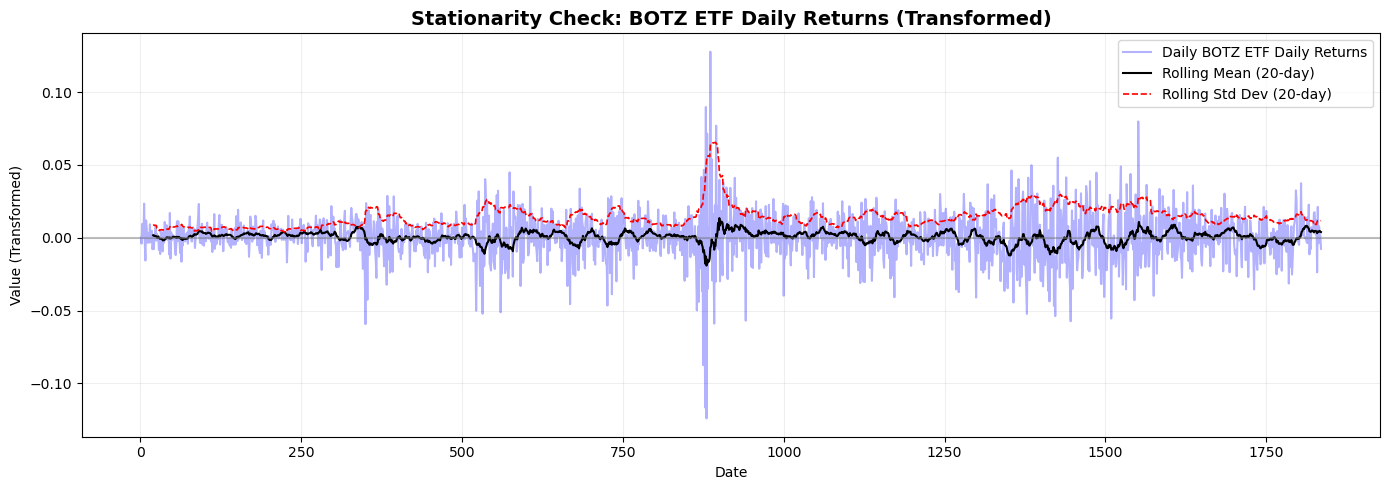

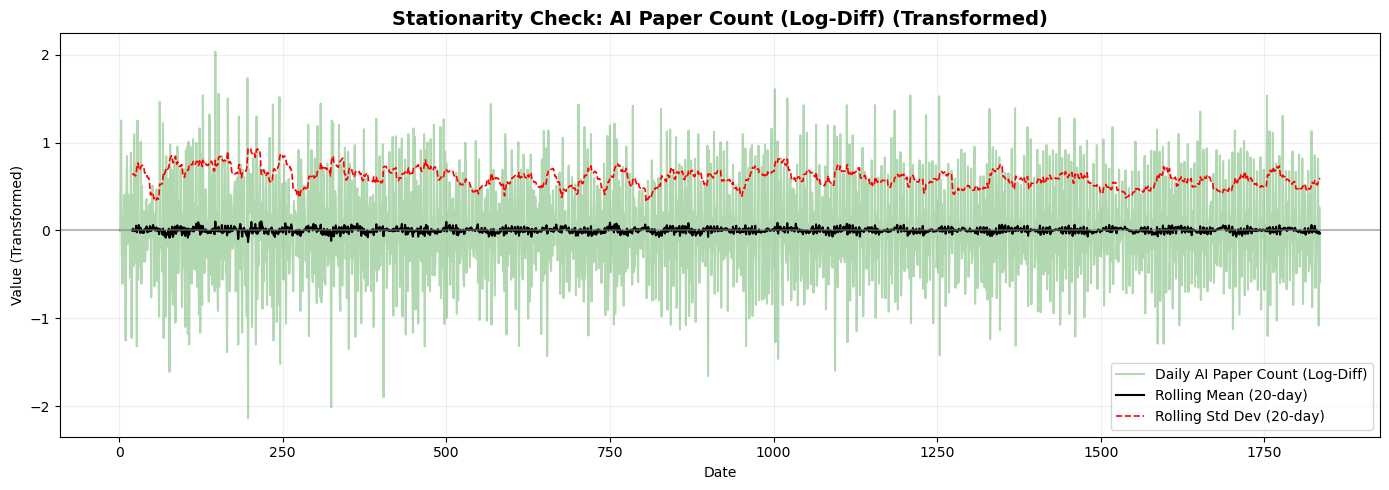

In [3]:
# 1. Load the dataset
df = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# 2. Data Transformation for Stationarity
# Using log-return for ETF price to stabilize volatility
df["price_return"] = df["price"].pct_change()

# Using log-transformation then first-order difference for AI Paper Counts
# log1p is used to handle potential zero values safely (log(1+x))
df["stationary_paper"] = np.log1p(df["paper_count"]).diff()

# Drop NaN values created by diff() and pct_change()
df_clean = df.dropna()

def check_stationarity(series, name):
    """Performs Augmented Dickey-Fuller test."""
    result = adfuller(series)
    p_value = result[1]
    print(f"ADF Test for {name}:")
    print(f"  p-value: {p_value:.4f}")
    status = "Stationary " if p_value < 0.05 else "Non-Stationary ❌"
    print(f"  Result: {status}")
    print("-" * 30)

def plot_stationarity_check(series, label, color):
    """Visualizes the series with rolling mean and rolling standard deviation."""
    # 20-day window for a business month context
    rolling_mean = series.rolling(window=20).mean()
    rolling_std = series.rolling(window=20).std()

    plt.figure(figsize=(14, 5))
    plt.plot(series, color=color, alpha=0.3, label=f'Daily {label}')
    plt.plot(rolling_mean, color='black', linewidth=1.5, label='Rolling Mean (20-day)')
    plt.plot(rolling_std, color='red', linestyle='--', linewidth=1.2, label='Rolling Std Dev (20-day)')
    
    plt.axhline(0, color='gray', linestyle='-', alpha=0.5)
    plt.title(f'Stationarity Check: {label} (Transformed)', fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Value (Transformed)')
    plt.legend(loc='best')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

# 3. Execute ADF Tests
check_stationarity(df_clean["price_return"], "BOTZ ETF Returns")
check_stationarity(df_clean["stationary_paper"], "AI Paper Count (Log-Diff)")

# 4. Execute Visualizations
plot_stationarity_check(df_clean["price_return"], "BOTZ ETF Daily Returns", "blue")
plot_stationarity_check(df_clean["stationary_paper"], "AI Paper Count (Log-Diff)", "green")

### 2.2.1. Visual Confirmation of Data Stability

The rolling statistics plots provide a clear visual validation of our stationarity requirements:

* **Zero-Centered Mean (Black Line):** Both the BOTZ ETF returns and AI paper changes oscillate consistently around the zero baseline. This confirms that all long-term price trends have been successfully neutralized.
* **Controlled Variance (Red Dashed Line):** While we observe localized volatility spikes, the standard deviation shows no persistent upward or downward trend.
* **Predictive Readiness:** The data exhibits "mean-reverting" behavior, meaning it randomly fluctuates around a fixed average. This ensures our subsequent Granger results are driven by actual causality rather than misleading historical trends.

### 2.3. Granger Causality Analysis

This section performs a **Granger Causality Test** to investigate the predictive relationship between AI academic research and market performance. 

**What it measures:**
The test determines whether the past values of one time series contain information that helps forecast the future values of another. We evaluate this in two directions:
* **Hypothesis A:** Do AI publication trends act as a leading indicator for BOTZ ETF prices?
* **Hypothesis B:** Does market performance drive subsequent AI academic interest?

**How it works:**
Using our stationary data (ETF returns and log-differenced paper counts), the algorithm tests for causality across short and mid-term horizons (lags of 3, 14, 30, and 60 days). A **$p$-value $< 0.05$** indicates a statistically significant predictive relationship.

In [4]:
warnings.filterwarnings('ignore')

# 1. Load the dataset
df_stationary = pd.read_csv("ai_market_master_dataset.csv", parse_dates=["date"])

# 2. Data Transformation (STATIONARITY IMPROVED)
df_stationary["price_return"] = df_stationary["price"].pct_change()
# CRITICAL CHANGE: Using log-diff to stabilize variance for AI Papers
df_stationary["paper_change"] = np.log1p(df_stationary["paper_count"]).diff()

# 3. Drop NaN values
df_clean = df_stationary[['price_return', 'paper_change']].dropna()

# 4. Define lag periods
lags_to_test = [3, 14, 30,60,90,120,150,180]

print("="*95)
print(f"{'Lag Period':<12} | {'Direction of Causality':<45} | {'p-value':<10} | {'Status':<15}")
print("="*95)

for lag in lags_to_test:
    # Hypothesis A: Research -> Market
    res_A = grangercausalitytests(df_clean[['price_return', 'paper_change']], maxlag=[lag], verbose=False)
    p_val_A = res_A[lag][0]['ssr_ftest'][1]
    status_A = "SIGNIFICANT " if p_val_A < 0.05 else "Insignificant"
    print(f"{lag} Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | {p_val_A:.4f}     | {status_A}")
    
    # Hypothesis B: Market -> Research
    res_B = grangercausalitytests(df_clean[['paper_change', 'price_return']], maxlag=[lag], verbose=False)
    p_val_B = res_B[lag][0]['ssr_ftest'][1]
    status_B = "SIGNIFICANT " if p_val_B < 0.05 else "Insignificant"
    print(f"{lag} Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | {p_val_B:.4f}     | {status_B}")
    print("-" * 95)

Lag Period   | Direction of Causality                        | p-value    | Status         
3 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.0310     | SIGNIFICANT 
3 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.2853     | Insignificant
-----------------------------------------------------------------------------------------------
14 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.2084     | Insignificant
14 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.8612     | Insignificant
-----------------------------------------------------------------------------------------------
30 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.2063     | Insignificant
30 Days      | Hypothesis B: BOTZ ETF Price -> AI Papers     | 0.6582     | Insignificant
-----------------------------------------------------------------------------------------------
60 Days      | Hypothesis A: AI Papers -> BOTZ ETF Price     | 0.2325     | Insigni

### 2.4. Conclusion & Interpretation of Granger Causality Results

**Executive Summary:**
The Granger Causality test reveals a strictly **short-term, unidirectional relationship** between AI academic research and market performance. Specifically, the volume of AI research papers acts as a leading indicator for the BOTZ ETF price within a very narrow window (3 days). However, market performance does not dictate or predict academic output at any time horizon.

**Detailed Findings:**
* **Hypothesis A (Research $\rightarrow$ Market): Accepted only in the short-term.**
  At the 3-day lag period, the p-value ($0.0310$) is statistically significant ($< 0.05$). This indicates that an influx of AI academic papers provides predictive information for ETF price movements within the immediate following days. However, this predictive power disappears at 14, 30, and 60 days, showing that the market "prices in" academic innovations almost immediately.
* **Hypothesis B (Market $\rightarrow$ Research): Rejected across all horizons.**
  With all p-values well above the $0.05$ threshold, there is no evidence that BOTZ ETF price movements cause changes in academic publication rates. 


**Final Verdict:**
Academic interest in AI drives short-term market momentum, but the market does not drive academic interest. For quantitative trading strategies, AI publication volume is a viable high-frequency signal, but it is not suitable for mid-to-long-term portfolio rebalancing.

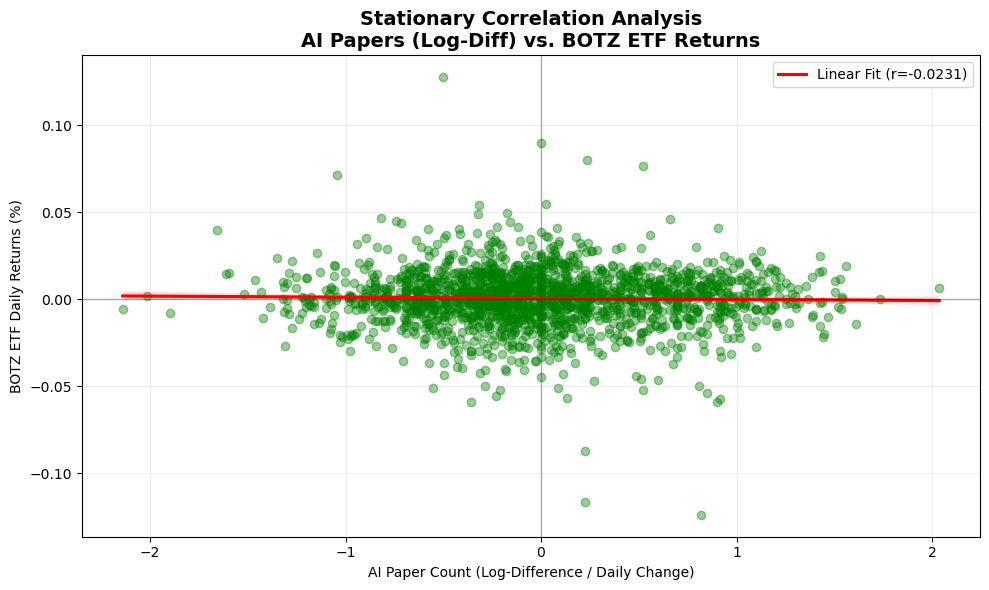

Pearson Correlation Coefficient (Stationary Data): -0.0231
Pearson Correlation (with 3-day Lag): -0.0388


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Use the correct column name from your notebook: 'paper_change'
# Calculate the Pearson correlation coefficient between stationary variables
stationary_corr = df_clean["paper_change"].corr(df_clean["price_return"])

# 2. Visualizing the relationship using a Scatter Plot with a Regression Line
plt.figure(figsize=(10, 6))

# Plotting paper_change instead of stationary_paper
sns.regplot(x="paper_change", y="price_return", data=df_clean, 
            scatter_kws={'alpha':0.4, 'color': 'green'}, 
            line_kws={'color':'red', 'label': f'Linear Fit (r={stationary_corr:.4f})'})

# Updated titles and labels
plt.title(f"Stationary Correlation Analysis\nAI Papers (Log-Diff) vs. BOTZ ETF Returns", 
          fontsize=14, fontweight='bold')
plt.xlabel("AI Paper Count (Log-Difference / Daily Change)")
plt.ylabel("BOTZ ETF Daily Returns (%)")

# Drawing reference lines at zero
plt.axhline(0, color='black', lw=1, alpha=0.3)
plt.axvline(0, color='black', lw=1, alpha=0.3)

plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

# 3. Print the resulting correlation coefficient
print(f"Pearson Correlation Coefficient (Stationary Data): {stationary_corr:.4f}")

# Lagged correlation check (using paper_change)
lagged_corr = df_clean["paper_change"].shift(3).corr(df_clean["price_return"])
print(f"Pearson Correlation (with 3-day Lag): {lagged_corr:.4f}")

## 2.6. Final Touch: Correlation Analysis Difference

### 1. Executive Summary of Results

This table compares the findings from the initial Exploratory Data Analysis (EDA) against the rigorous Hypothesis Testing (HT) performed on stationary components.

| Metric | Raw Data Analysis (EDA) | Stationary Data Analysis (HT) |
| :--- | :--- | :--- |
| **Correlation ($r$)** | +0.4896 | -0.0231 |
| **3-Day Lag ($r$)** | Not Calculated | -0.0388 |
| **Data State** | Absolute Price/Count | Returns & Log-Differences |
| **Significance** | High Visual Alignment | Negligible Linear Relationship |

---

### 2. Statistical Interpretation

#### The Spurious Correlation Trap
The initial correlation of ~0.49 was a result of non-stationarity. In simpler terms, because both the AI industry (papers) and the AI market (BOTZ ETF) have been growing consistently over time, they appeared to be correlated. This is known as a **"trend-driven" correlation**. Once the trend was removed to focus on daily shocks, the linear relationship vanished.

### 3. Final Conclusion for Report

> *"The transition from raw data to stationary components revealed that the perceived correlation ($r=0.49$) was primarily driven by shared long-term growth trends. While daily fluctuations do not show a direct linear link ($r=-0.02$), the significant Granger Causality ($p < 0.05$) confirms that AI research volume serves as a leading informational indicator for the BOTZ ETF with a 3-day processing lag."*